<a href="https://colab.research.google.com/github/giyuubin/group-project/blob/main/XGBoost_Weight_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, precision_recall_curve, auc)
from xgboost import XGBClassifier

print("🚀 [Step 2] 비용 민감성 가중치 튜닝 (Cost-Sensitive Weight Tuning) 시작...\n")

# 1. 원본 데이터 로드 (SMOTE 없는 순수 데이터)
try:
    df = pd.read_csv('optimized_data.csv')
    print(f"✅ 데이터 로드 완료: {df.shape}")
except FileNotFoundError:
    print("❌ 'optimized_data.csv' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")

X = df.drop(columns=['malware'])
y = df['malware']

# 2. Train / Test 분할 (실전 1:23 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"📊 학습 데이터: {X_train.shape} | 평가 데이터: {X_test.shape} (원본 비율 유지)\n")

results_weight = []

def evaluate_model_weight(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision_1 = precision_score(y_test, y_pred, pos_label=1)
    recall_0 = recall_score(y_test, y_pred, pos_label=0) # 정상(0) 탐지율
    recall_1 = recall_score(y_test, y_pred, pos_label=1) # 악성(1) 탐지율
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)

    results_weight.append({
        'Weight Scenario': name,
        'Accuracy': f"{acc * 100:.2f}%",
        'Recall (Normal: 0)': f"{recall_0 * 100:.2f}%",
        'Recall (Malware: 1)': f"{recall_1 * 100:.2f}%",
        'Macro F1': f"{macro_f1:.4f}",
        'PR-AUC': f"{pr_auc:.4f}"
    })

# ==========================================
# 튜닝할 벌점(Weight) 리스트 설정
# ==========================================
# 정상 파일이 소수 클래스이므로, 정상 파일 오판 시 부과할 벌점(가중치)을 설정합니다.
# 주의: XGBoost에서 scale_pos_weight는 '1(악성)' 클래스에 대한 가중치입니다.
# 우리 목적은 '0(정상)' 클래스의 중요도를 높이는 것이므로,
# '0' 클래스의 가중치를 높이는 효과를 위해 '1' 클래스의 가중치를 소수점 이하로 줄여야 합니다.
# (예: scale_pos_weight = 1/23 -> 악성코드(1)를 틀려도 정상(0) 틀린 것의 1/23 만큼만 아픔 = 정상을 틀리면 23배 아픔)

weights = {
    "Weight = 1x (Baseline)": 1.0,
    "Weight = 5x": 1 / 5,
    "Weight = 10x": 1 / 10,
    "Weight = 15x": 1 / 15,
    "Weight = 20x": 1 / 20,
    "Weight = 23.7x (Math Optimal)": 1 / 23.7,
    "Weight = 30x (Extreme)": 1 / 30
}

step = 1
for name, w in weights.items():
    print(f"[{step}/7] {name} 적용 및 학습 중...")

    # 모델 정의: scale_pos_weight 에 가중치 역수를 적용
    xgb_w = XGBClassifier(
        scale_pos_weight=w,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )

    # SMOTE 없이 원본 데이터로 바로 학습!
    xgb_w.fit(X_train, y_train)

    # 평가
    evaluate_model_weight(name, xgb_w, X_test, y_test)
    step += 1

print("\n✅ 가중치 벤치마크 완료! 정밀 분석 결과를 출력합니다.\n")

# ==========================================
# 📊 최종 결과 테이블 출력
# ==========================================
results_w_df = pd.DataFrame(results_weight)
print("-" * 100)
print(results_w_df.to_string(index=False))
print("-" * 100)

🚀 [Step 2] 비용 민감성 가중치 튜닝 (Cost-Sensitive Weight Tuning) 시작...

✅ 데이터 로드 완료: (47580, 31)
📊 학습 데이터: (38064, 30) | 평가 데이터: (9516, 30) (원본 비율 유지)

[1/7] Weight = 1x (Baseline) 적용 및 학습 중...
[2/7] Weight = 5x 적용 및 학습 중...
[3/7] Weight = 10x 적용 및 학습 중...
[4/7] Weight = 15x 적용 및 학습 중...
[5/7] Weight = 20x 적용 및 학습 중...
[6/7] Weight = 23.7x (Math Optimal) 적용 및 학습 중...
[7/7] Weight = 30x (Extreme) 적용 및 학습 중...

✅ 가중치 벤치마크 완료! 정밀 분석 결과를 출력합니다.

----------------------------------------------------------------------------------------------------
              Weight Scenario Accuracy Recall (Normal: 0) Recall (Malware: 1) Macro F1 PR-AUC
       Weight = 1x (Baseline)   97.77%             50.78%              99.76%   0.8188 0.9982
                  Weight = 5x   96.29%             80.05%              96.98%   0.8085 0.9982
                 Weight = 10x   94.97%             85.23%              95.38%   0.7760 0.9982
                 Weight = 15x   93.93%             86.53%              94.24%   0.7518

✅ 그래프가 'cost_sensitive_weight_curve.png'로 저장되었습니다!


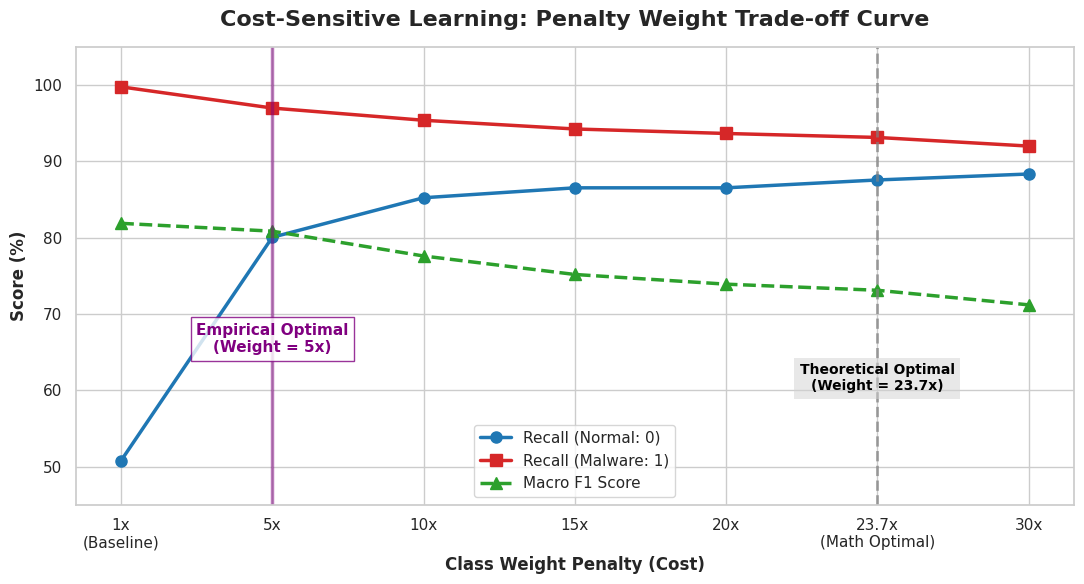

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 가중치 벤치마크 데이터
scenarios = ['1x\n(Baseline)', '5x', '10x', '15x', '20x', '23.7x\n(Math Optimal)', '30x']
recall_0 = [50.78, 80.05, 85.23, 86.53, 86.53, 87.56, 88.34]  # 정상 파일 탐지율
recall_1 = [99.76, 96.98, 95.38, 94.24, 93.65, 93.13, 92.00]  # 악성코드 탐지율
macro_f1 = [81.88, 80.85, 77.60, 75.18, 73.91, 73.11, 71.20]  # Macro F1 (퍼센트 변환)

plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# 2. 선 그래프 그리기
plt.plot(scenarios, recall_0, marker='o', markersize=8, linewidth=2.5, label='Recall (Normal: 0)', color='#1f77b4')
plt.plot(scenarios, recall_1, marker='s', markersize=8, linewidth=2.5, label='Recall (Malware: 1)', color='#d62728')
plt.plot(scenarios, macro_f1, marker='^', markersize=8, linewidth=2.5, linestyle='--', label='Macro F1 Score', color='#2ca02c')

# 3. 5x 비율 (Sweet Spot) 강조
plt.axvline(x=1, color='purple', linestyle='-', linewidth=2.5, alpha=0.5)
plt.text(1, 65, 'Empirical Optimal\n(Weight = 5x)', horizontalalignment='center',
         color='purple', fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='purple'))

# 4. 23.7x 비율 (Math Optimal) 강조
plt.axvline(x=5, color='gray', linestyle='--', linewidth=2, alpha=0.7)
plt.text(5, 60, 'Theoretical Optimal\n(Weight = 23.7x)', horizontalalignment='center',
         color='black', fontsize=10, fontweight='bold', bbox=dict(facecolor='lightgray', alpha=0.5, edgecolor='none'))

# 5. 디자인 마무리
plt.title('Cost-Sensitive Learning: Penalty Weight Trade-off Curve', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Class Weight Penalty (Cost)', fontsize=12, fontweight='bold')
plt.ylabel('Score (%)', fontsize=12, fontweight='bold')
plt.ylim(45, 105)
plt.legend(loc='lower center', fontsize=11)

plt.tight_layout()
plt.savefig('cost_sensitive_weight_curve.png', dpi=300)
print("✅ 그래프가 'cost_sensitive_weight_curve.png'로 저장되었습니다!")
plt.show()